# Extra Credit Activities 2: Stepper Motor controller (Class)

> Create a class for controlling a stepper motor.

Type:
- [x] Extra Credit Activities (Individual, 4 points)
- [ ] Portfolio

Student information
  - Student name: **INSERT YOUR NAME HERE**
  - Student mail: **INSERT YOUR STUDENT MAIL HERE**

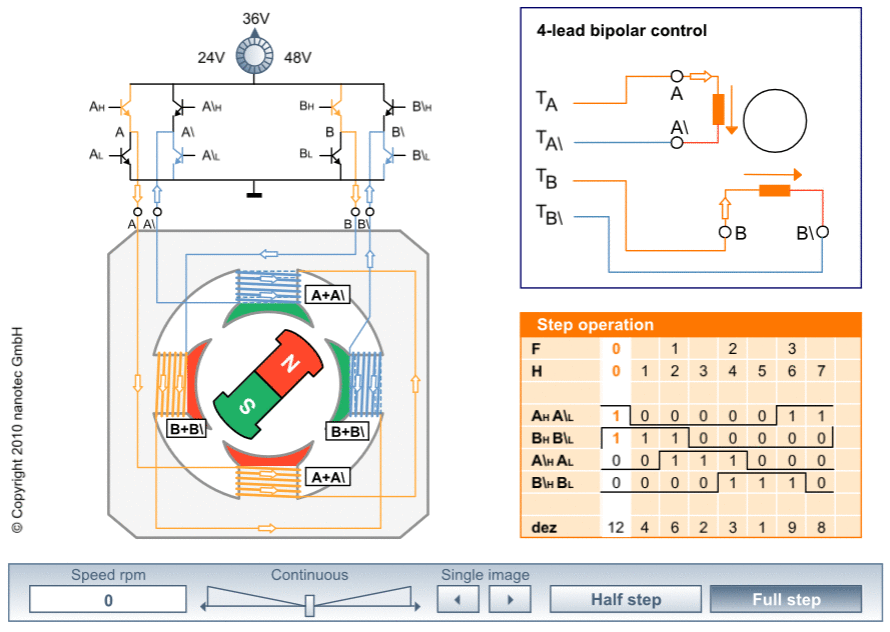

[Stepper motor animation](https://www.nanotec.com/eu/en/knowledge-base/stepper-motor-animation)

# Dummy classes (testing only)
> These dummy classes are for testing only

This imports a dummy ```Pin``` and ```PWM``` class from the machine module, which allows to simulate control over the GPIO pins.

__Remember__ to import the following, when tesing on the Raspberry Pi Pico / Pico W:

```
from machine import Pin, PWM
```

## PIN Class (dummy)
> This dummy class is for testing only

In [ ]:
class Pin:
    # Pin modes
    IN = 0
    OUT = 1

    def __init__(self, pin, mode=-1, pull=-1, value=None, drive=0, alt=-1):
        """
        Initialize a Pin object.

        Parameters:
            pin (int): The pin number.
            mode (int): The pin mode (IN, OUT, etc.).
            pull (int): The pull mode (PULL_UP, PULL_DOWN, etc.).
            value (int, optional): The initial pin value.
            drive (int): The drive strength.
            alt (int): Alternate function.
        """
        self.pin = pin
        self.mode = mode
        self.pull = pull
        self.value = value
        self.drive = drive
        self.alt = alt


## PWM Class (dummy)
> This dummy class is for testing only

In [ ]:
class PWM:
    def __init__(self, pin):
        self.pin = pin
        self._frequency = 1000
        self._duty = 0

    def freq(self, frequency):
        """
        Set the frequency for PWM signals.

        :param frequency: Frequency in Hz.
        """
        self._frequency = frequency
        #print(f"Set frequency to {frequency} Hz")

    def duty_u16(self, duty):
        """
        Set the duty cycle for PWM signals.

        :param duty: Duty cycle as a 16-bit value (0-65535).
        """
        self._duty = duty
        #print(f"Set duty cycle to {duty}")

# Stepper Motor example

## Example code: Full step sequence for a Stepper motor

In [ ]:
import time

def initialize_pins(pins):
    return [PWM(Pin(pin)) for pin in pins]

def set_frequency(pins, frequency):
    for pin in pins:
        pin.freq(frequency)

def move_stepper(pins, steps, pct=0.15, delay=0.001):


    pwm_max = 65535
    pwm_pct = pct
    pwm_val = int(pwm_max * pwm_pct)

    step_sequence = [
        [pwm_val, pwm_val, 0, 0],
        [0, pwm_val, pwm_val, 0],
        [0, 0, pwm_val, pwm_val],
        [pwm_val, 0, 0, pwm_val],
    ]

    if delay < 0.0001:
        delay = 0.0001
        print("! Delay limit !")

    steps = abs(steps)

    for cnt in range(steps):
        print(cnt)
        for step in range(len(step_sequence)):
            set_step(pins, step_sequence[step])
            print("{} --> {}".format(step,step_sequence[step]))
            time.sleep(delay)

    stop(pins)

def set_step(pins, step):
    for pin in range(len(pins)):
        pins[pin].duty_u16(step[pin])

def stop(pins):
    stop_sequence = [0, 0, 0, 0]
    print("Stop --> {}".format(stop_sequence))
    set_step(pins, stop_sequence)

## Unit test

In [ ]:
pin_numbers = [16, 17, 18, 19]

pins = initialize_pins(pin_numbers)

set_frequency(pins, 16_000)

steps = 1
pct = 0.5
delay = 1

move_stepper(pins, steps, pct, delay)

stop(pins)

## Source code (full code example)

> __Note:__ This example will not work in a Jupyter Notebook since ```machine``` is a MicroPython-specific module. The example is ment for executing it on the physical device.

**A button press (`GP27`) activates the stepper sequence as a safety to ensure not burning the hardware.**



In [ ]:
from machine import Pin, PWM
import time

# Initialize the button pin as input with an internal pull-up resistor
sw_push = Pin('GP27', Pin.IN, Pin.PULL_UP) # Vores knap, behøves ikke PULL_UP resistor da den gør det for os.
sw_en = False # Variabel der holder styr på om knappen er trykket ned eller ej, sat på false som default.

# Define the ISR for button press
def handle_button_interrupt(pin):
    if pin.value() == 0:  # Button pressed (active low)
        print('SW PUSH pressed!')

        # ?
        steps = 50
        pct = 0.5
        delay = 0.01

        move_stepper(pins, steps, pct, delay)

        # ?
        stop(pins)
    else:  # Button released
        print('SW PUSH released!')

# Attach the interrupt to the button pin
# Trigger on both falling and rising edges to detect both press and release
sw_push.irq(trigger=Pin.IRQ_FALLING | Pin.IRQ_RISING, handler=handle_button_interrupt)


# Starter PWM på pins og laver en liste af PWM objekter til vores move_stepper funktion
def initialize_pins(pins):
    return [PWM(Pin(pin)) for pin in pins]

# Vi sætter en frekvens for PWM på vores pins
def set_frequency(pins, frequency):
    for pin in pins:
        pin.freq(frequency)

# Funktonen tager input of oversætter det til en sekvens af microsteps som flytter stepper.
def move_stepper(pins, steps, pct=0.15, delay=0.001):
    """
    Move the stepper motor a specified number of steps.

    :param pins: ?
    :param steps: ?
    :param delay: ?
    """

    pwm_max = 65535
    pwm_pct = pct
    pwm_val = int(pwm_max * pwm_pct)

    # How many steps for each sequence?
    step_sequence = [
        [pwm_val, pwm_val, 0, 0],
        [0, pwm_val, pwm_val, 0],
        [0, 0, pwm_val, pwm_val],
        [pwm_val, 0, 0, pwm_val],
    ]

    if delay < 0.0001:
        delay = 0.0001
        print("! Delay limit !")

    steps = abs(steps)

    for cnt in range(steps):
        print(cnt)
        for step in range(len(step_sequence)):
            set_step(pins, step_sequence[step])
            print("{} --> {}".format(step,step_sequence[step]))
            time.sleep(delay)

    # IMPORTANT #
    stop(pins)

# funktion sætter PWM for hver pin.
def set_step(pins, step):
    for pin in range(len(pins)):
        pins[pin].duty_u16(step[pin])

# funktion der tager alle "coils" og deaktiverer dem.
def stop(pins):
    stop_sequence = [0, 0, 0, 0]
    print("Stop --> {}".format(stop_sequence))
    set_step(pins, stop_sequence)



# Vores pin-numre.
pin_numbers = [0, 1, 2, 3]

# tager de pins i pin_numbers at vi bruger
pins = initialize_pins(pin_numbers)

# Sætter frekvens for PWM på vores pins
set_frequency(pins, 16_000)



# Assignments

## Assignment 1: Verify and document the Stepper Motor example



1.1: Run the full code example above on your test PCB, and observe its behaviour. Consider questions in Hand-in section
1. D10 LED lyser når 18V er tilsluttet, D9 lyser afhængigt af vores potentiometer.
2. Vores `move_stepper(pins, 1, 1)` kalder funktionen "move_steppers" med inputs 1 fuldt step(4 Mikrosteps) på 100% power, pins indikerer vores PWM-kanaler objekter. Dertil er delay standart på 0.001 fordi vi ikkke specificerede det.
3. Hvis vi ændrer værdierne kan vi ændre hvor mange fulde steps vi tager og med hvr stor en del af max pwm vi vil bruge samt vores hastighed i delay, kortere delay = hurigere rotation med mindre kraftmoment.

1.2: Finalize the Comments in Source Code (full code example); replace each of the placeholder comments marked with "# ?", with a meaningful comment that accurately describes what the code directly below it does.

## Assignment 2: Create a Stepper Motor Class




2.1: Make a Stepper Motor Controller Class from your working example with a half stepper sequence, with the following parameters:
* `pins`: List of GPIO pin numbers connected to the motor driver.
* `pwm_pct`: Percentage of the maximum PWM duty cycle.
* `frequency`: Frequency for the PWM signals.

Use the example below as a starting point:

In [ ]:
class StepperMotor:
    def __init__(self, pins, pwm_pct = 0.15, frequency=18_000):
        """
        Initialize a StepperMotor object.

        :param pins: List of GPIO pin numbers connected to the motor driver.
        :param pwm_pct: Percentage of the maximum PWM duty cycle.
        :param frequency: Frequency for the PWM signals.
        """

        # ...continue your work here



2.2: Validate your implememntation of the StepperMotor Class using the LEDs
 * (..so similar to the example above, just using your own the class).

In [ ]:
# Example usage
if __name__ == '__main__':

    # Initialize a StepperMotor object for the left motor.
    # Parameters:
    #   - [A, B, C, D]: List of GPIO pins connected to the motor.
    #   - 0.15: The delay between each step in seconds.
    #   - 18_000: Total number of steps the motor can make.
    left_motor = StepperMotor([16, 17, 18, 19], 0.2, 18_000)

    # Move the stepper motor.
    # Parameters:
    #   - 2: Number of steps sequences to move.
    #   - 0.1: Speed factor or additional delay between steps (to adjust the speed).
    steps = 2
    delay = 0.1
    left_motor.move_stepper(steps, delay)

2.3: Make a function for moving the stepper either `forward` or `backward`,

In [ ]:
# Example

def move_stepper(self, steps, direction, delay=0.001):
    """
    Move the stepper motor a specified number of steps.
    :param steps: Number of steps to move. Positive for forward, negative for backward.
    :param direction: Direction to move. "forward" for forward, "backward" for backward.
    :param delay: Delay between steps in seconds.
    """

2.4: Make a variable that keeps track / counts the total number of steps taken since initialization, such that

* Moving forward = Counting up
* Moving backward = Counting down

2.5: Make a function that keeps rotating the motor continuously in same direction.



## Assignment 3: Implement and validate the half stepper sequence


**3.1:** Expand the `step_sequence` such that the stepper motor can perform a half step sequence, and test the half step sequence using the LEDs onboard the test PCB.

In [ ]:
step_sequence = [
    [pwm_val, 0, 0, 0],                  # Full step
    [pwm_val, pwm_val, 0, 0],            # Half step

    # ...continue your work here
]

**3.2:** Record that you can run the half step sequence on the PCB with 25%, 50% and 100% PWM. 

## Assignment 4: Test the half stepper sequence with a real Stepper Motor

**4.1: Physical setup - Validate your code with a Stepper Motor**

***Stepper motor:***
* **Model:** 17HE19-2004S
* **Type:** Bipolar NEMA 17 stepper motor
* **Specifications:** 1.8° step angle, 2.0 A/phase, 1.4 Ω phase resistance.

***Practice PCB:***
* **Motor Driver IC (L293NE):**
  * **Type:** Quadruple high-current half-H driver
  * **Specifications:** Capable of handling up to 1A per channel.

Connect your Practice PCB to a power supply, and use the following settings:

* **Output:** 18V (constant voltage)
* **Current limit:** 0.5A (ensure that you don't burn the L293NE)

and for your `StepperMotor` class:
* Set the pins for the motor
  * `pin_numbers = [0, 1, 2, 3]`
* Ensure not to put to much load on the driver
  * `steps = 200`
  * `pwm_pct = 0.5`
  * `delay = 0.01`
  * Start with the potentiometer in the middle.
  * (When you have the system running, adjust the values to see how it affects the performance of the stepper motor, ***but be aware of the notes below!***)

**Note:** Too many `print` statements can result in slowing down your code, use them for debugging only, and comment out when not needed to get a more smooth running motor.

When testing, **be aware of**:
* Not stopping the Raspberry Pi Pico using Thonny(when running a program)
* Not changing the PWM (`pwm_pct`) to above 0.3
* Always check the temperature of the L293:
  * it will heat up if you put to high of a load on it.
  * it will shut down if it gets to hot, but over time, it will get destroyed.

**4.2: Tweak the settings**

Adjust the setting for controlling one stepper motor, such that it:

* runs smoothly, and
* with enough tourqe

**4.3: Record your result**

Record that your PCB can command a stepper motor to make one full rotation (360 degrees). Make it visible, eg. by putting a piece of tape on the shaft of the motor.

*INSERT THE LINK TO THE VIDEO DOWN IN **HAND-IN** SECTION*


### Images of a test setup

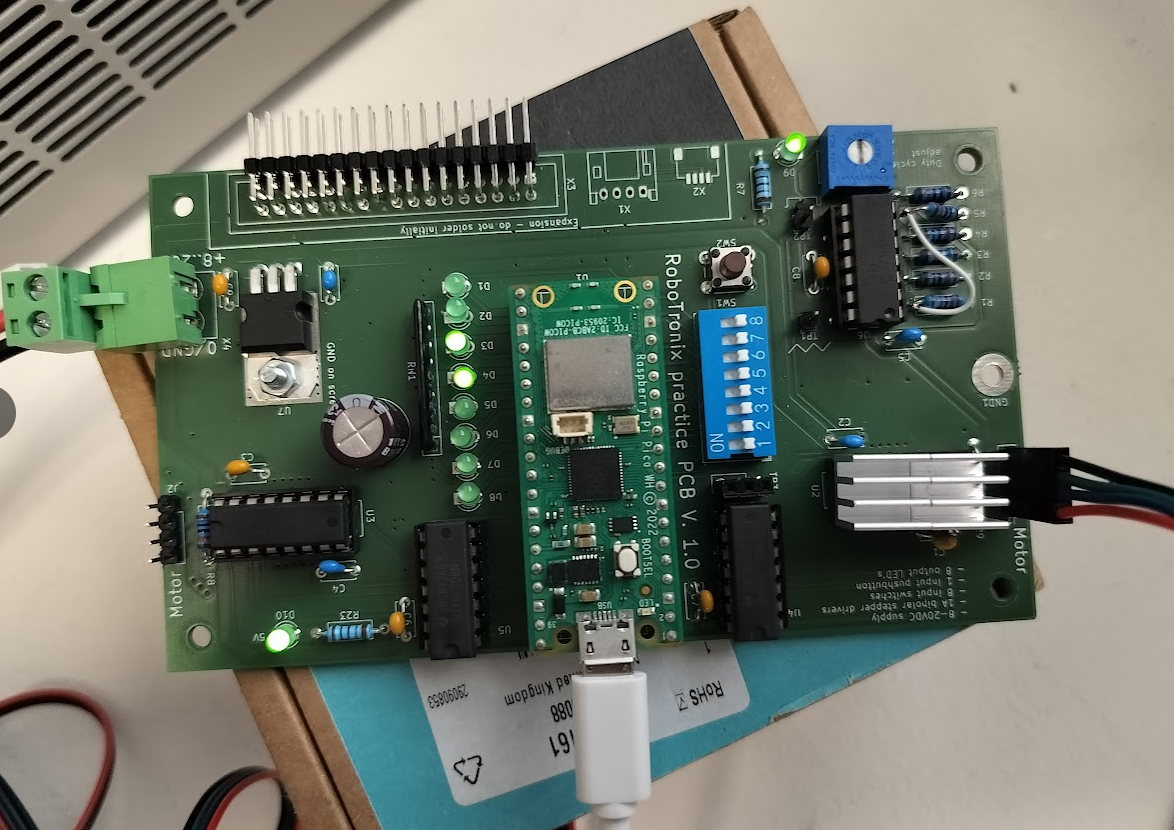

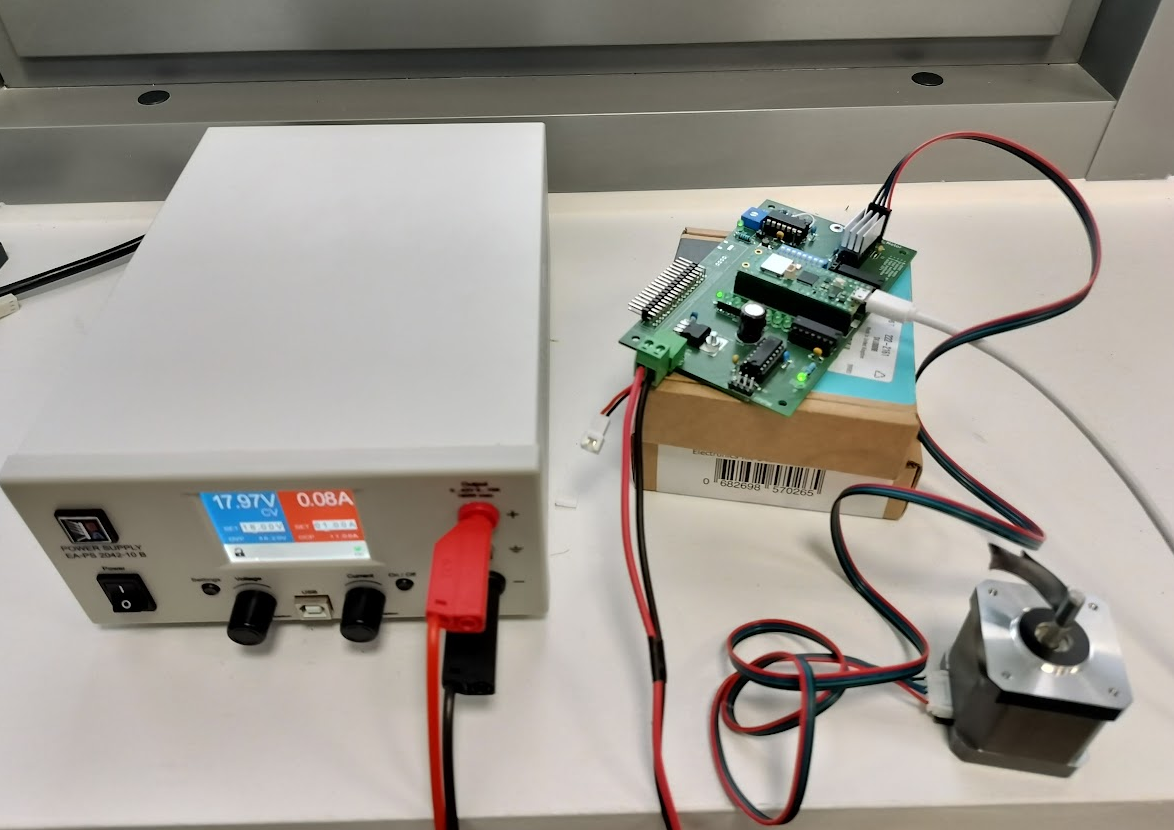

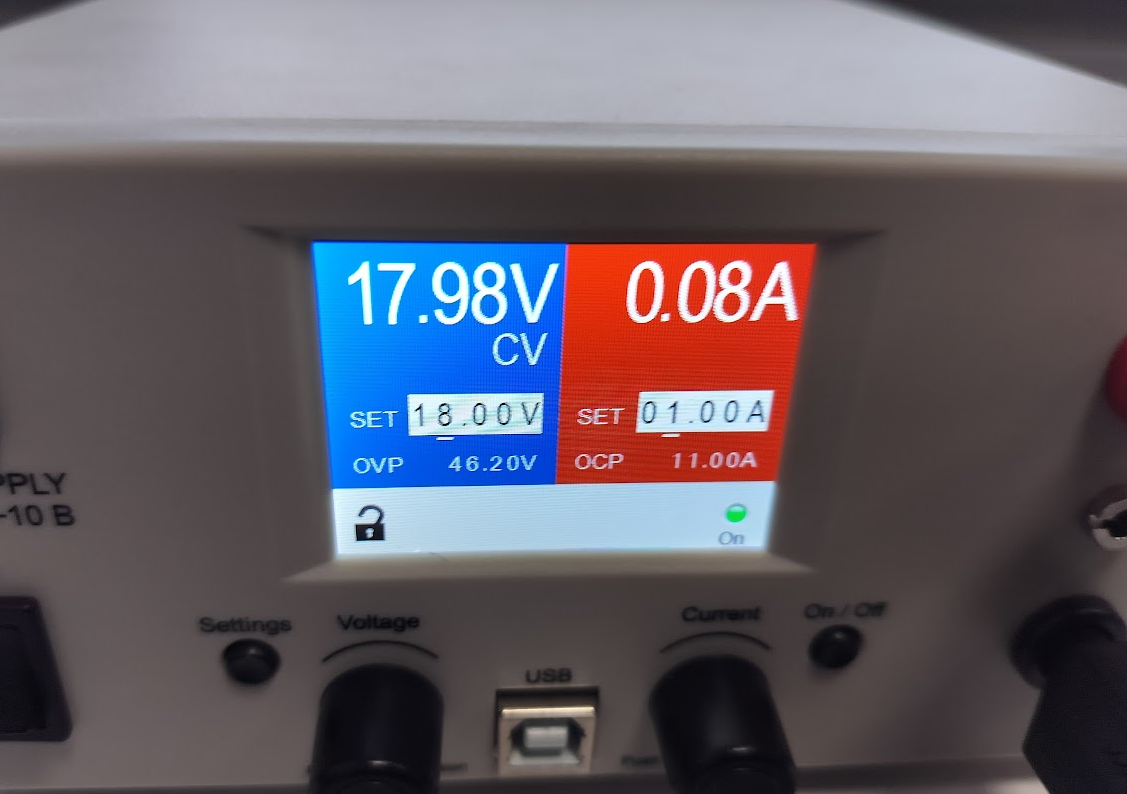

## Assingment 5: Implement and validate a micro stepper sequence.

**5.1:** Expand the `step_sequence` such that the stepper motor can perform a micro step sequence (see the [stepper motor animation](https://www.nanotec.com/eu/en/knowledge-base/stepper-motor-animation)), and validate the step sequence using the LEDs onboard the test PCB.

Start with hard-coding the `step_sequence` and validate it works as intended with smaller steps first, and then start expanding the sequence. Use the code snippet below as an example.

In [ ]:
step_sequence = [
    [pwm_val, 0, 0, 0],                  # Full step
    [pwm_val, pwm_val//2, 0, 0],         # Microstep 1
    [pwm_val, pwm_val, 0, 0],            # Half step

    # ...continue your work here

    [pwm_val, 0, 0, pwm_val//2],         # Microstep 8
]

**(optional)** Make a function for auto-generating the `step_sequence` based on the desired micro-step size.

**5.2:** Record that you can run the micro step sequence on the PCB using its LEDs. 

*INSERT THE LINK TO THE VIDEO DOWN IN **HAND-IN** SECTION*

## Assignment 6: Test the micro stepper sequence with a real Stepper Motor

**6.1: Physical setup - Validate your code with a Stepper Motor**

Similar setup as described in 4.1,

**6.2: Tweak the settings**

Adjust the setting for controlling one stepper motor, such that it:

* runs smoothly, and
* with enough tourqe

**6.3: Record your result**

Record that your PCB can command a stepper motor to make one full rotation (360 degrees). Make it visible, eg. by putting a piece of tape on the shaft of the motor.

*INSERT THE LINK TO THE VIDEO DOWN IN **HAND-IN** SECTION*


## (Optional) Assignment 7: Optimize your Stepper Motor class

6.1: Make the motor ramp up slowly, when starting a `move_stepper`.


# Hand-in (Deadline: 12/10, 23:59)

Assignment 1:
- 1.1 - Run the full code example in section 1 on your test PCB, and observe its behaviour. Consider the qeustions below:
    * What happens with the LEDs?
    * What does the `move_stepper(pins, 1, 1)` do?
    * What happens if you change its values? What are the affect of each parameter?

- 1.2 - Finalize the Comments in Source Code (full code example) 

## Video

Assignment 3.2:
  * Insert the link to your video below.

    * 25% PWM: ***INSERT THE LINK TO THE VIDEO HERE***
    * 50% PWM: ***INSERT THE LINK TO THE VIDEO HERE***
    * 100% PWM: ***INSERT THE LINK TO THE VIDEO HERE***

    **or**

   * Showcase all in one video: ***INSERT THE LINK TO THE VIDEO HERE***

Assignment 4.3:
  * Link to video: **INSERT THE LINK TO YOUR VIDEO**

  
Assignment 5.2:
  * Link to video: **INSERT THE LINK TO YOUR VIDEO**

Assignment 6.3:
  * Link to video: **INSERT THE LINK TO YOUR VIDEO**

  


## Source code


**3.3:** Insert your source code

In [ ]:
# Insert the source code for your Stepper Motor class with the half stepper sequence

and how to test it:


In [ ]:
# insert a example usage

**5.3:** Insert your source code

In [ ]:
# Insert the source code for your Stepper Motor class with the micro stepper sequence

and how to test it:

In [ ]:
# insert a example usage

Insert your source code for your final implementation of your `StepperMotor` class and a example usage of it:

File: `main.py`

In [ ]:
# Example usage
# - Inser your main loop here, if any, and how you includes your StepperMotor class

File: `stepper_motor.py`

In [ ]:
# Insert the class for your final version of the Stepper Motor class